In [1]:
import os; os.makedirs("qapinn", exist_ok=True)
os.makedirs("outputs", exist_ok=True); os.makedirs("checkpoints", exist_ok=True)

In [2]:
!python solver_spectral.py && python solver_fdm.py && python solver_fem.py
from ground_truth import cross_validate
GTS, xval = cross_validate()
GT = GTS["spectral"]

spectral: (201, 1024) u range -1.0 1.0
fdm: (2001, 1001) u range -1.0 1.0
fem: (4001, 801) u range -1.0 1.0
    t |  FDM vs SPEC |  FEM vs SPEC
 0.25 |    6.219e-04 |    3.041e-04
 0.50 |    2.166e-03 |    6.739e-04
 0.75 |    1.824e-03 |    4.752e-04
 1.00 |    1.443e-03 |    3.775e-04


### **Classical PINN Results**

[adam ]      0 | 2.8503e+01 | pde 9.07e-01 ic 2.71e-01 bc 1.11e+00 | 1.4s
[adam ]    500 | 6.2595e-01 | pde 4.29e-01 ic 7.57e-03 bc 2.28e-03 | 10.4s
[adam ]   1000 | 3.8371e-01 | pde 3.32e-01 ic 1.94e-03 bc 6.34e-04 | 18.8s
[adam ]   1500 | 3.4841e-01 | pde 3.14e-01 ic 1.38e-03 bc 3.56e-04 | 27.4s
[adam ]   2000 | 3.3454e-01 | pde 2.93e-01 ic 1.69e-03 bc 4.04e-04 | 36.0s
[adam ]   2500 | 3.1378e-01 | pde 2.89e-01 ic 1.20e-03 bc 3.39e-05 | 45.1s
[adam ]   3000 | 3.0536e-01 | pde 2.81e-01 ic 1.19e-03 bc 1.28e-05 | 54.5s
[adam ]   3500 | 2.9879e-01 | pde 2.75e-01 ic 1.18e-03 bc 1.38e-05 | 63.9s
[adam ]   4000 | 2.9362e-01 | pde 2.68e-01 ic 1.24e-03 bc 3.55e-05 | 72.8s
[adam ]   4500 | 2.8804e-01 | pde 2.65e-01 ic 1.15e-03 bc 2.14e-05 | 82.2s
[adam ]   5000 | 2.8339e-01 | pde 2.60e-01 ic 1.17e-03 bc 2.66e-05 | 92.4s
[adam ]   5500 | 2.7898e-01 | pde 2.56e-01 ic 1.14e-03 bc 2.28e-05 | 102.4s
[adam ]   6000 | 2.7479e-01 | pde 2.52e-01 ic 1.14e-03 bc 2.42e-05 | 112.4s
[adam ]   6500 | 2.7051e

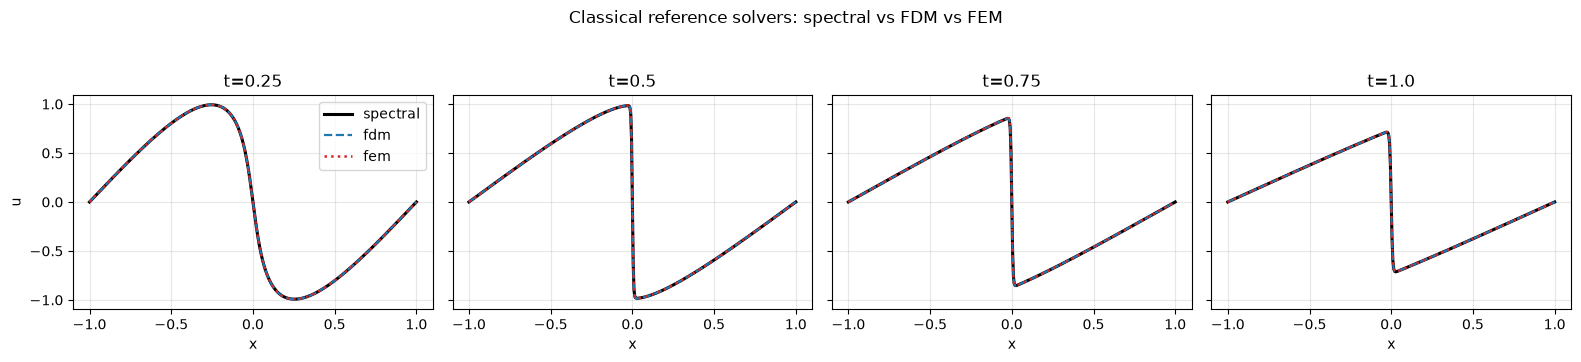

saved outputs/heat_pinn.png


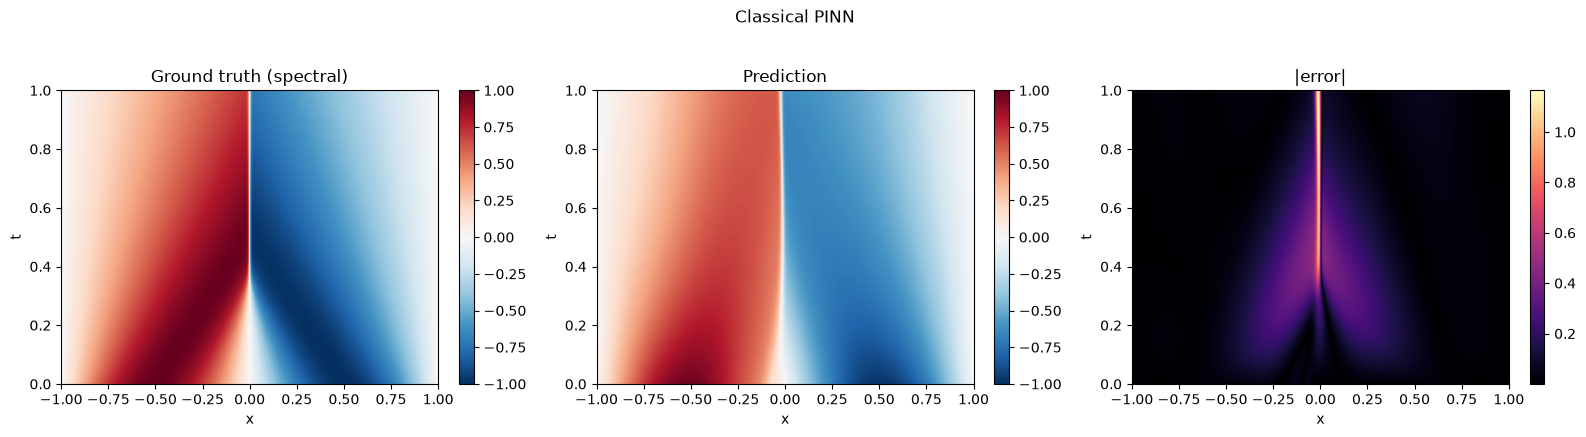

saved outputs/snap_pinn.png


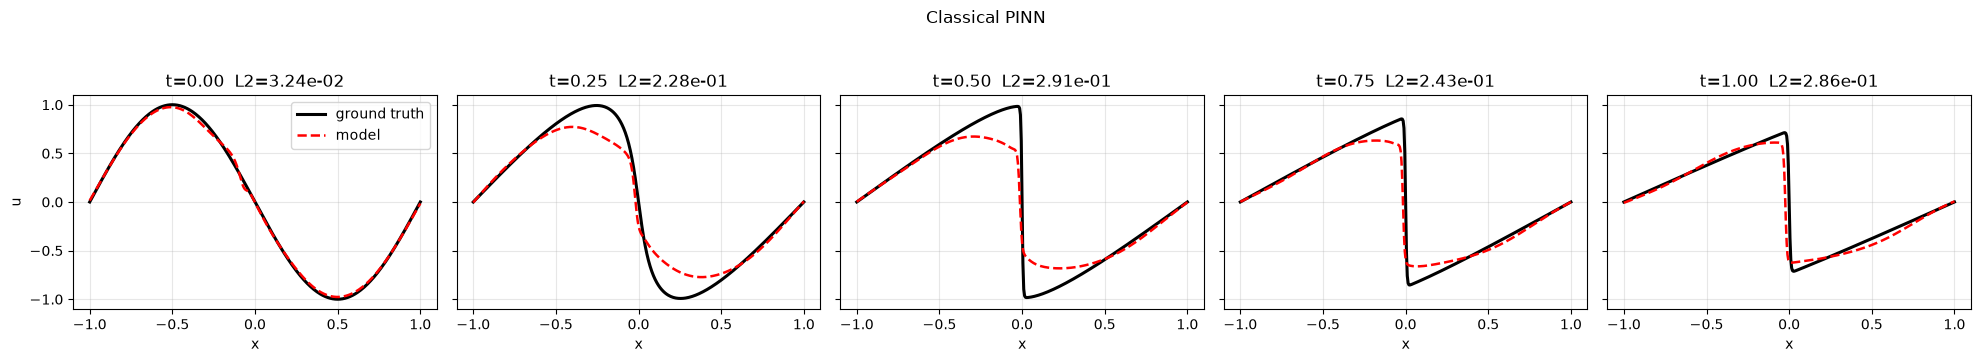

In [3]:
from train import train_classical
from evaluate import evaluate
import viz, numpy as np
from models import ClassicalPINN

SNAPS = (0, 200, 1000, 4000, 10000, 14999)
pinn, hist_pinn, snaps_pinn = train_classical(
    depth=4, width=8, adam_epochs=15000, lbfgs_iter=0, snapshot_epochs=SNAPS)

res_pinn = evaluate(pinn, GT)
print("PINN rel-L2:", res_pinn["l2_global"])

viz.solver_comparison(GTS)
viz.heatmap_triptych(res_pinn, "Classical PINN", "heat_pinn")
viz.snapshots(res_pinn, title="Classical PINN", name="snap_pinn")

## **Classical PINN hidden layer**

saved outputs/hidden_maps_pinn.png


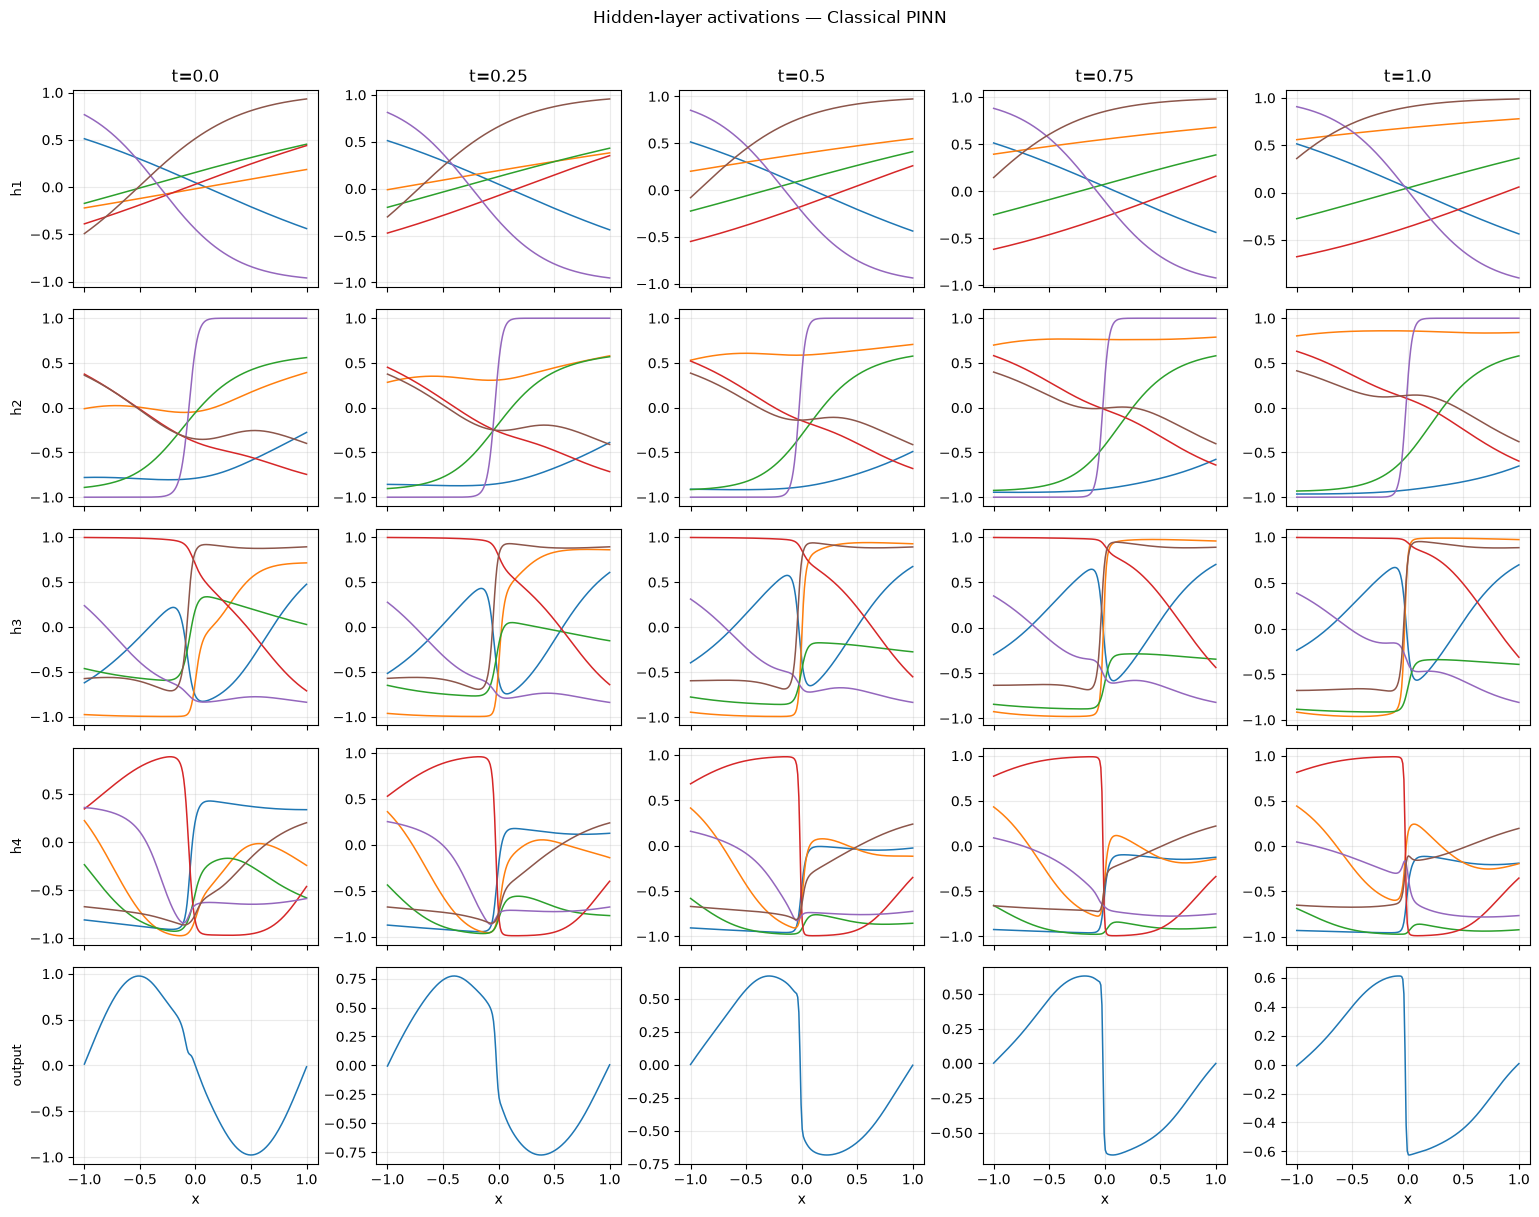

saved outputs/hidden_heat_pinn.png


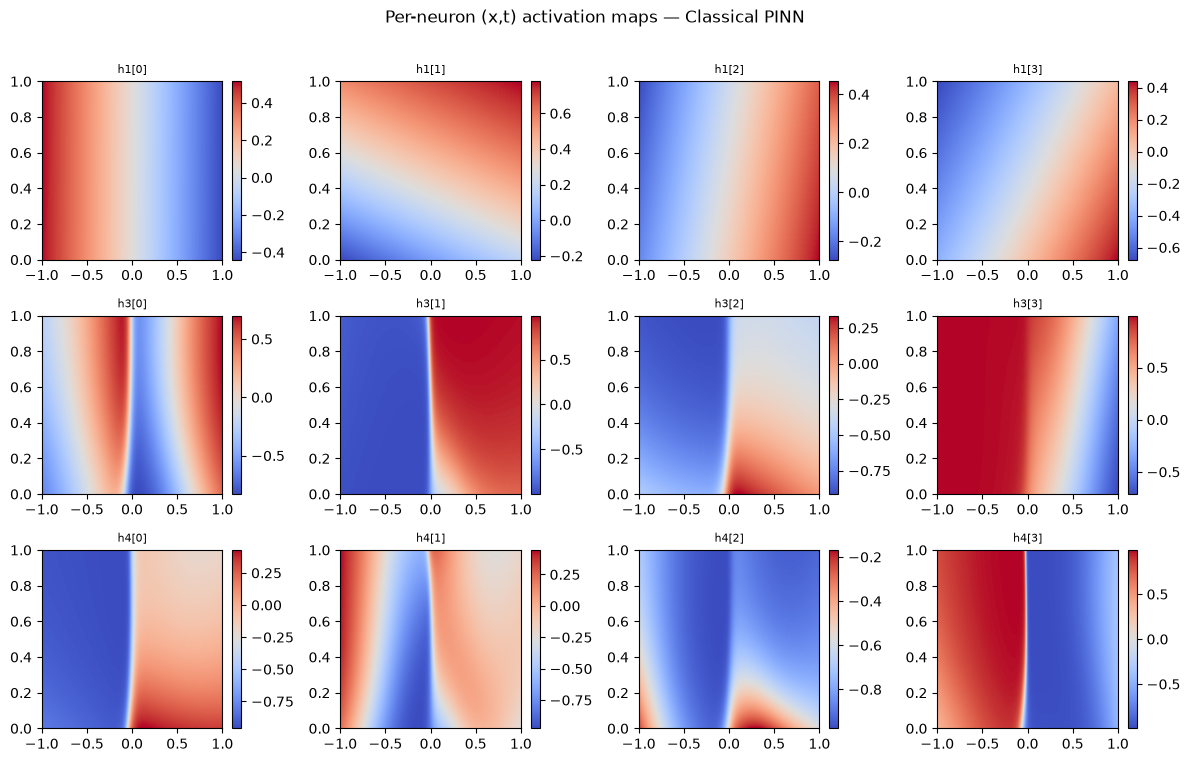

saved outputs/hidden_pca_pinn.png


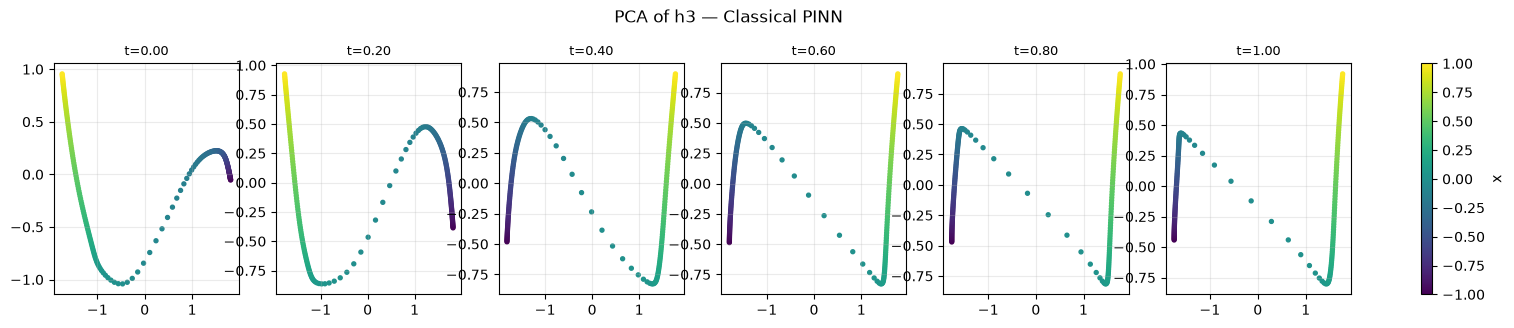

saved outputs/layer_evol_pinn.png


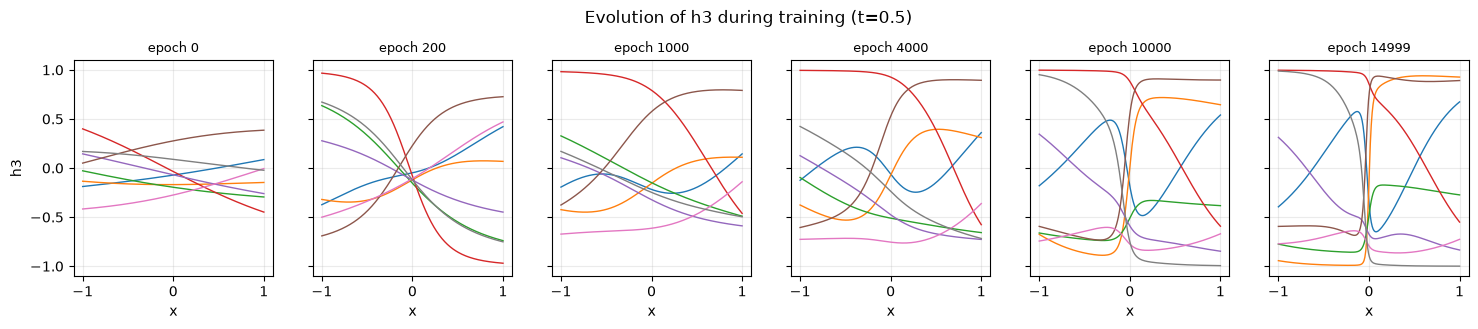

In [4]:
viz.hidden_layer_maps(pinn, ts=(0.0,0.25,0.5,0.75,1.0),
                      title="Classical PINN", name="hidden_maps_pinn")
viz.hidden_layer_heatmaps(pinn, layer_keys=["h1","h3","h4"],
                          title="Classical PINN", name="hidden_heat_pinn")
viz.hidden_pca_trajectory(pinn, layer="h3", title="Classical PINN",
                          name="hidden_pca_pinn")
viz.layer_evolution_during_training(ClassicalPINN, snaps_pinn,
        dict(depth=4, width=8), layer="h3", name="layer_evol_pinn")

## **QAPINN Sweep**

[3q L4 ru=1]     0 | 1.1177e+01 | pde 8.36e-04 ic 5.18e-01 bc 4.08e-02 | 0.5s
[3q L4 ru=1]   200 | 6.2364e-01 | pde 4.59e-01 ic 5.95e-03 bc 2.30e-03 | 79.8s
[3q L4 ru=1]   400 | 4.7252e-01 | pde 3.92e-01 ic 3.11e-03 bc 9.34e-04 | 160.6s
[3q L4 ru=1]   600 | 4.1653e-01 | pde 3.62e-01 ic 2.12e-03 bc 5.99e-04 | 241.7s
[3q L4 ru=1]   800 | 3.9612e-01 | pde 3.50e-01 ic 1.84e-03 bc 4.83e-04 | 323.9s
[3q L4 ru=1]  1000 | 3.8595e-01 | pde 3.45e-01 ic 1.70e-03 bc 3.72e-04 | 419.5s
[3q L4 ru=1]  1200 | 3.8072e-01 | pde 3.42e-01 ic 1.62e-03 bc 3.22e-04 | 503.5s
[3q L4 ru=1]  1400 | 3.7781e-01 | pde 3.40e-01 ic 1.58e-03 bc 3.08e-04 | 586.8s
[3q L4 ru=1]  1600 | 3.7621e-01 | pde 3.39e-01 ic 1.57e-03 bc 3.05e-04 | 670.8s
[3q L4 ru=1]  1800 | 3.7551e-01 | pde 3.38e-01 ic 1.56e-03 bc 3.05e-04 | 746.6s
[3q L4 ru=1]  1999 | 3.7535e-01 | pde 3.38e-01 ic 1.56e-03 bc 3.05e-04 | 822.8s
3q rel-L2 = 5.7219e-01
saved outputs/heat_qapinn_3q.png


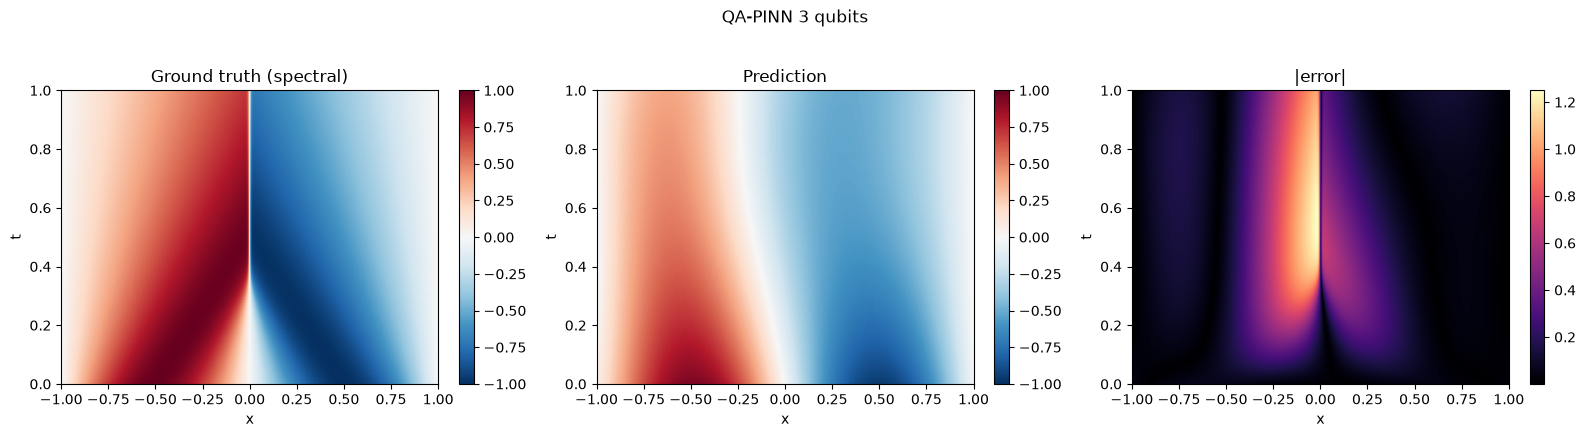

[4q L4 ru=1]     0 | 1.1236e+01 | pde 2.24e-04 ic 5.33e-01 bc 2.86e-02 | 0.6s
[4q L4 ru=1]   200 | 4.4758e-01 | pde 3.50e-01 ic 3.33e-03 bc 1.56e-03 | 125.4s
[4q L4 ru=1]   400 | 3.8533e-01 | pde 3.21e-01 ic 2.32e-03 bc 9.18e-04 | 258.6s
[4q L4 ru=1]   600 | 3.6276e-01 | pde 3.10e-01 ic 1.92e-03 bc 7.22e-04 | 392.9s
[4q L4 ru=1]   800 | 3.5003e-01 | pde 3.04e-01 ic 1.70e-03 bc 6.04e-04 | 520.8s
[4q L4 ru=1]  1000 | 3.4277e-01 | pde 3.01e-01 ic 1.59e-03 bc 5.26e-04 | 645.8s
[4q L4 ru=1]  1200 | 3.3866e-01 | pde 2.99e-01 ic 1.52e-03 bc 4.74e-04 | 772.5s
[4q L4 ru=1]  1400 | 3.3632e-01 | pde 2.98e-01 ic 1.49e-03 bc 4.40e-04 | 902.0s
[4q L4 ru=1]  1600 | 3.3507e-01 | pde 2.97e-01 ic 1.47e-03 bc 4.22e-04 | 1041.6s
[4q L4 ru=1]  1800 | 3.3454e-01 | pde 2.97e-01 ic 1.46e-03 bc 4.14e-04 | 1173.3s
[4q L4 ru=1]  1999 | 3.3442e-01 | pde 2.97e-01 ic 1.46e-03 bc 4.12e-04 | 1305.4s
4q rel-L2 = 5.3755e-01
saved outputs/heat_qapinn_4q.png


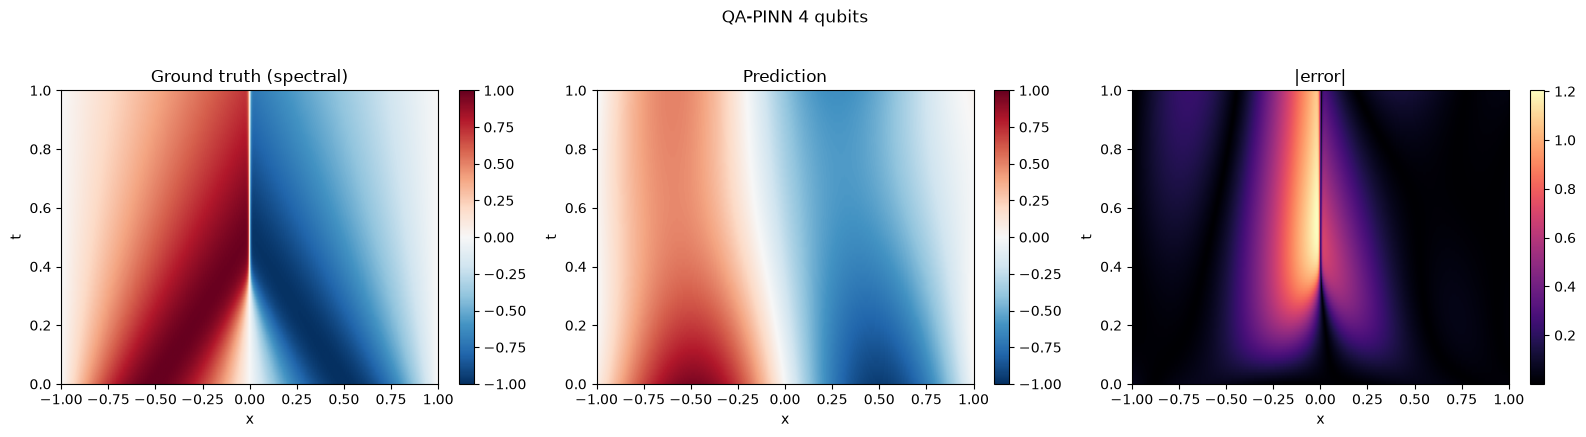

[5q L4 ru=1]     0 | 1.1759e+01 | pde 1.62e-04 ic 5.42e-01 bc 4.55e-02 | 1.1s
[5q L4 ru=1]   200 | 5.9462e-01 | pde 4.03e-01 ic 5.49e-03 bc 4.08e-03 | 221.6s
[5q L4 ru=1]   400 | 3.5446e-01 | pde 3.08e-01 ic 1.95e-03 bc 3.90e-04 | 436.3s
[5q L4 ru=1]   600 | 3.2428e-01 | pde 2.91e-01 ic 1.56e-03 bc 8.78e-05 | 652.0s
[5q L4 ru=1]   800 | 3.1763e-01 | pde 2.88e-01 ic 1.44e-03 bc 5.85e-05 | 864.9s
[5q L4 ru=1]  1000 | 3.1315e-01 | pde 2.85e-01 ic 1.38e-03 bc 4.92e-05 | 1076.9s
[5q L4 ru=1]  1200 | 3.0997e-01 | pde 2.82e-01 ic 1.34e-03 bc 4.67e-05 | 1296.7s
[5q L4 ru=1]  1400 | 3.0791e-01 | pde 2.80e-01 ic 1.33e-03 bc 4.64e-05 | 1520.7s
[5q L4 ru=1]  1600 | 3.0675e-01 | pde 2.80e-01 ic 1.32e-03 bc 4.66e-05 | 1743.0s
[5q L4 ru=1]  1800 | 3.0626e-01 | pde 2.79e-01 ic 1.31e-03 bc 4.67e-05 | 1979.1s
[5q L4 ru=1]  1999 | 3.0614e-01 | pde 2.79e-01 ic 1.31e-03 bc 4.68e-05 | 2208.5s
5q rel-L2 = 4.6606e-01
saved outputs/heat_qapinn_5q.png


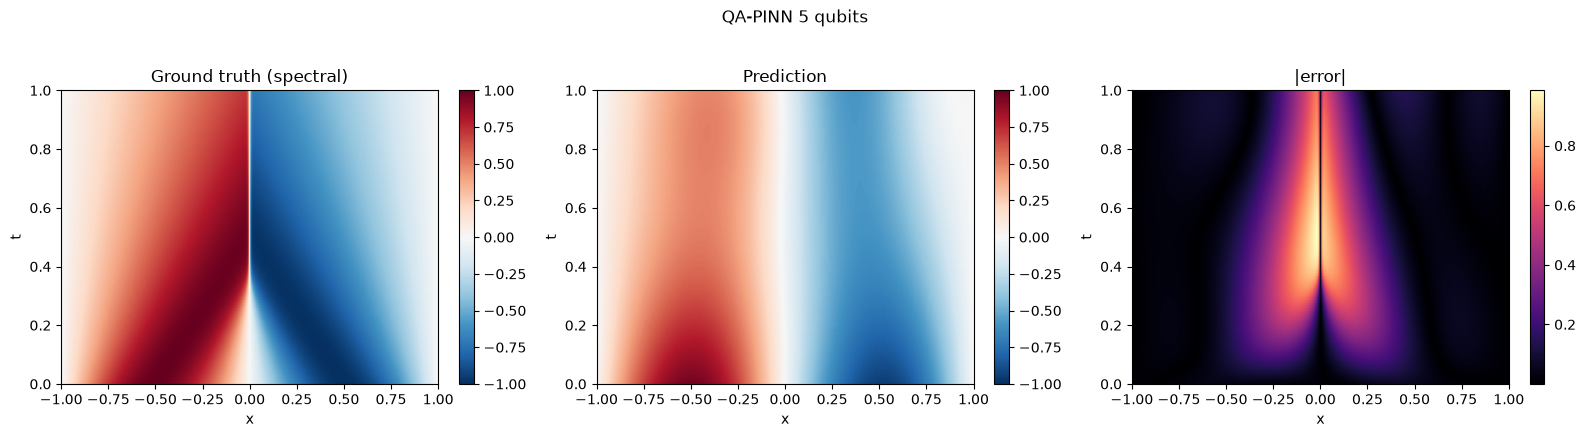

In [5]:
from train_qapinn import train_qapinn
from models import QAPINN

QSNAPS = (0, 200, 1000, 3000, 5999)
qmodels, qhists, qsnaps, qres = {}, {}, {}, {}
for nq in (3,4,5):
    m,h,s = train_qapinn(n_qubits=nq, n_layers=4, hidden=8, reupload=True, epochs=2000, n_pde=256, snapshot_epochs=QSNAPS)
    qmodels[nq], qhists[nq], qsnaps[nq] = m,h,s
    qres[nq] = evaluate(m, GT)
    print(f"{nq}q rel-L2 = {qres[nq]['l2_global']:.4e}")
    viz.heatmap_triptych(qres[nq], f"QA-PINN {nq} qubits", f"heat_qapinn_{nq}q")

### **Loss Curves**

saved outputs/loss_all.png


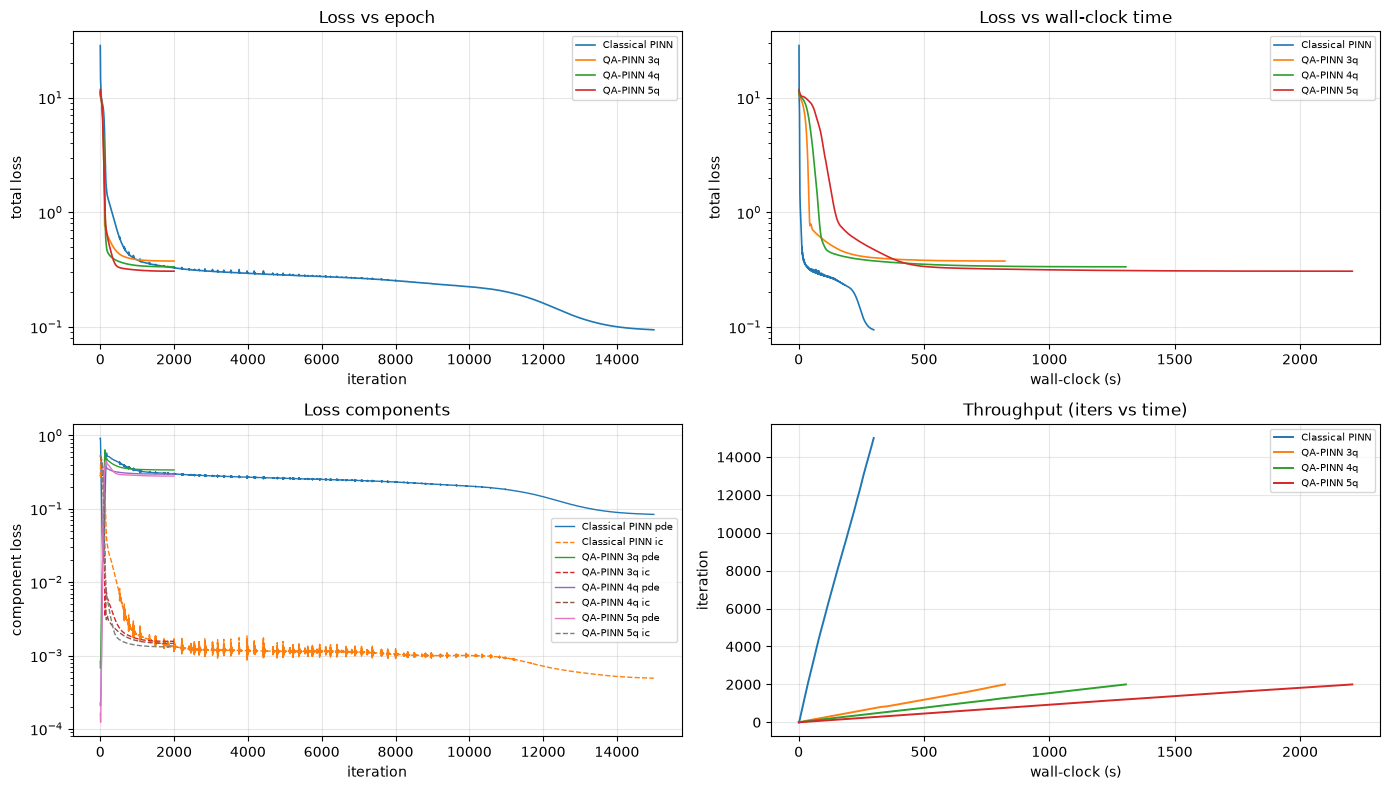

In [6]:
H = {"Classical PINN": hist_pinn}
H.update({f"QA-PINN {n}q": qhists[n] for n in (3,4,5)})
viz.loss_curves(H, name="loss_all")

### **QAPINN Hidden Layers**

saved outputs/hidden_maps_qapinn_3q.png


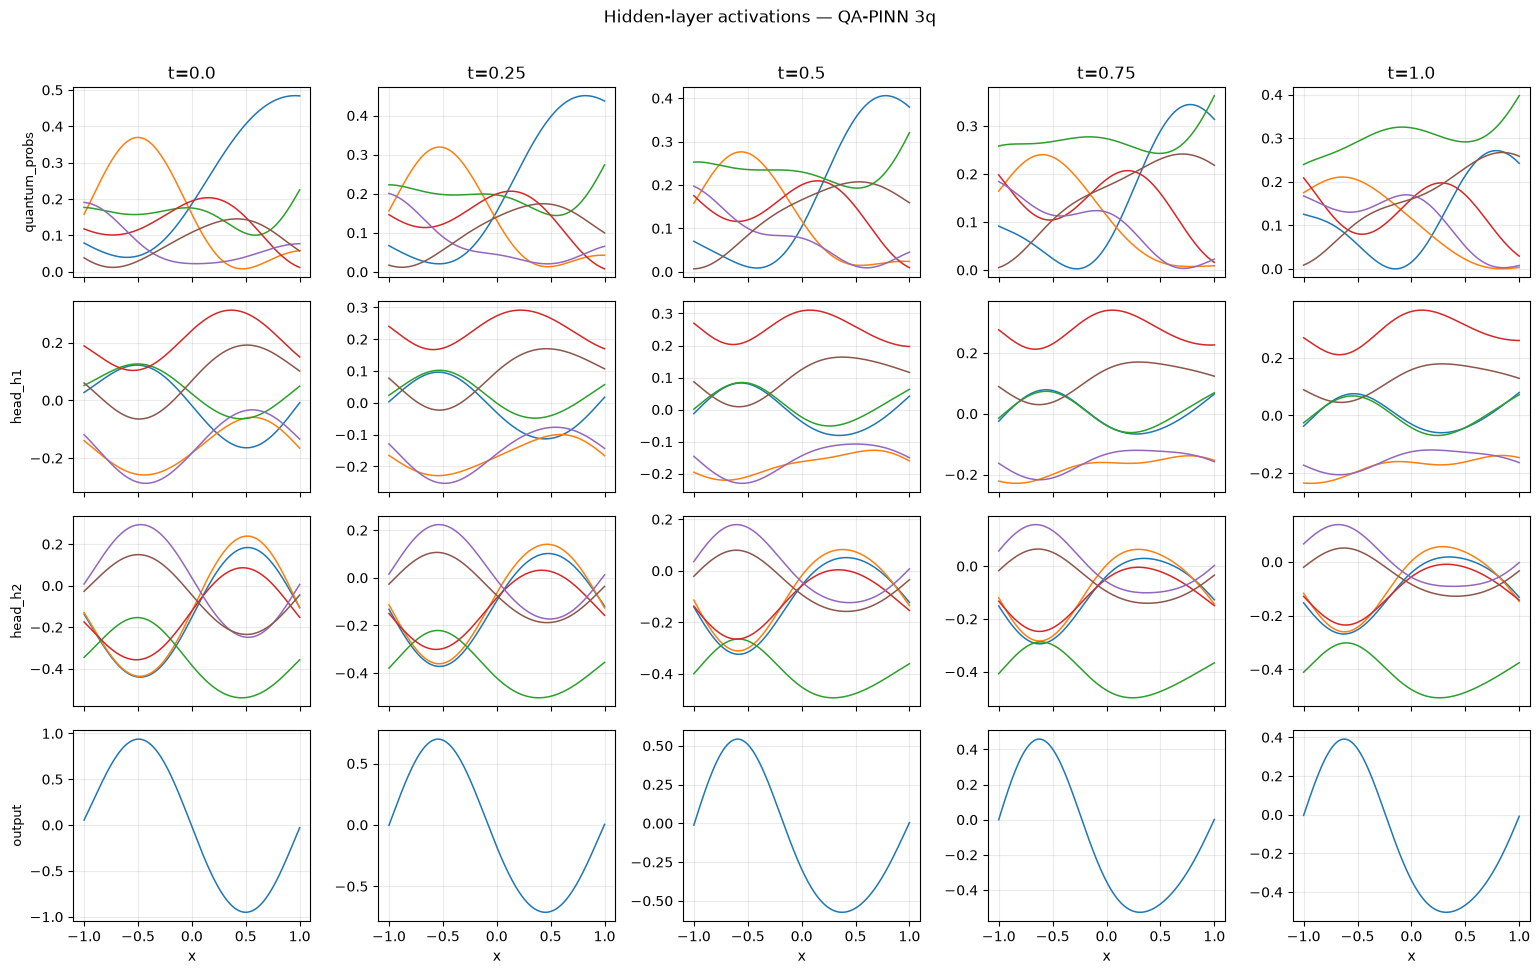

saved outputs/hidden_heat_qapinn_3q.png


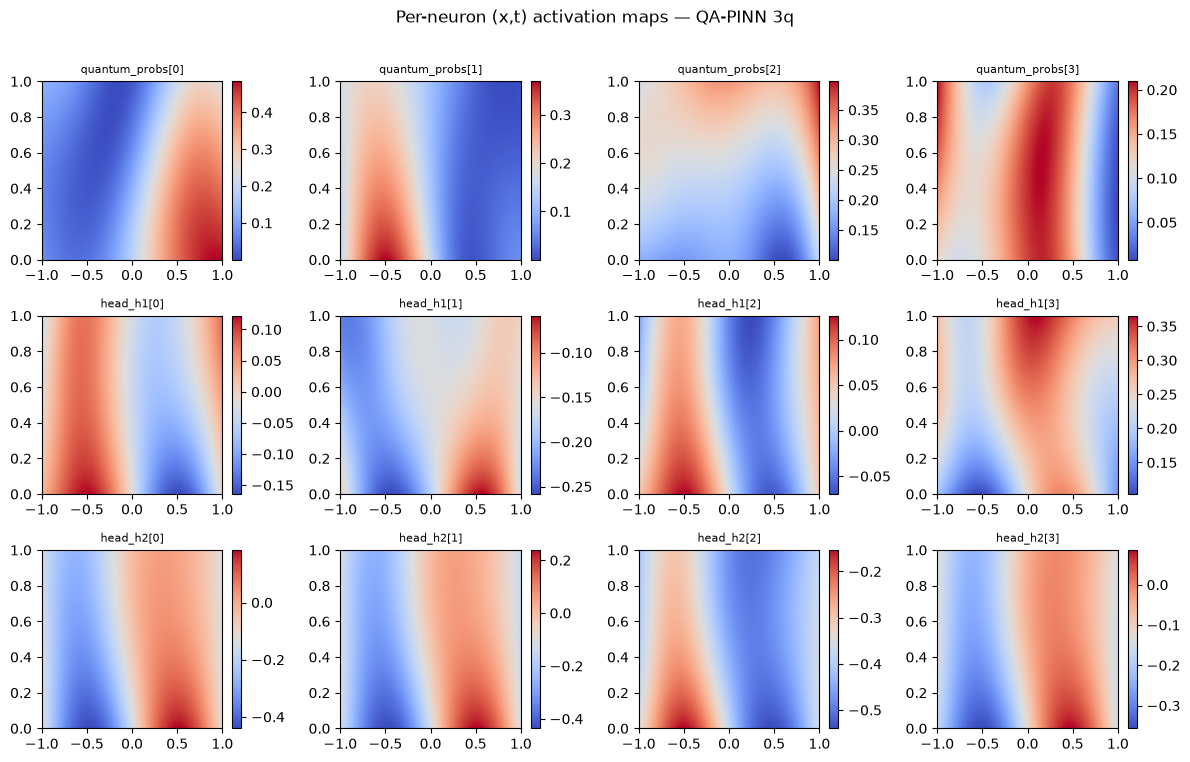

saved outputs/hidden_pca_qapinn_3q.png


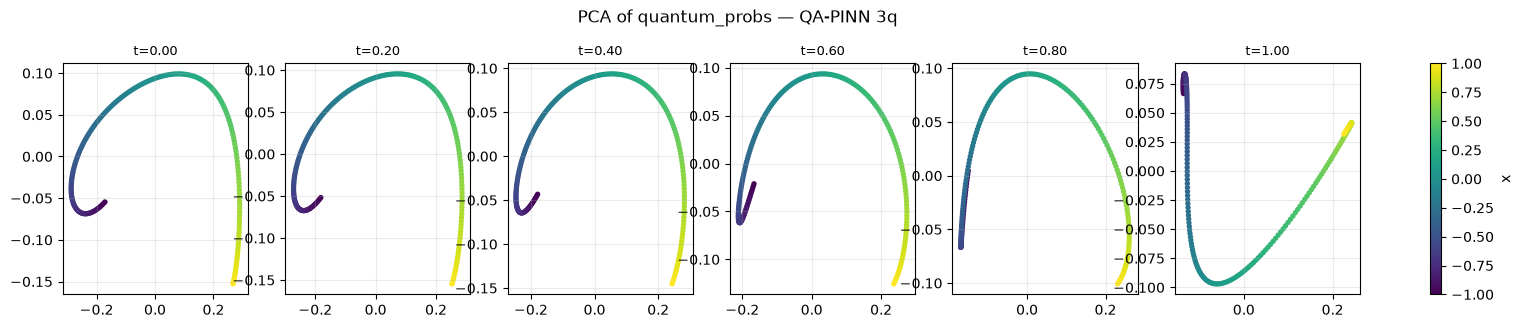

RuntimeError: Error(s) in loading state_dict for QAPINN:
	size mismatch for q_weights: copying a param with shape torch.Size([4, 3, 2]) from checkpoint, the shape in current model is torch.Size([8, 3, 2]).
	size mismatch for head.0.weight: copying a param with shape torch.Size([8, 8]) from checkpoint, the shape in current model is torch.Size([32, 8]).
	size mismatch for head.0.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for head.2.weight: copying a param with shape torch.Size([8, 8]) from checkpoint, the shape in current model is torch.Size([32, 32]).
	size mismatch for head.2.bias: copying a param with shape torch.Size([8]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for head.4.weight: copying a param with shape torch.Size([1, 8]) from checkpoint, the shape in current model is torch.Size([1, 32]).

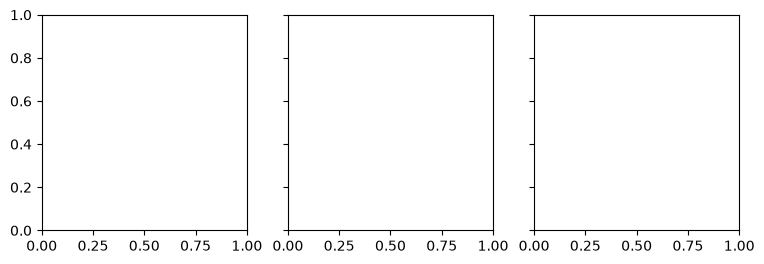

In [7]:
for nq in (3,4,5):
    viz.hidden_layer_maps(qmodels[nq],
        layer_keys=["quantum_probs","head_h1","head_h2","output"],
        title=f"QA-PINN {nq}q", name=f"hidden_maps_qapinn_{nq}q")
    viz.hidden_layer_heatmaps(qmodels[nq],
        layer_keys=["quantum_probs","head_h1","head_h2"],
        title=f"QA-PINN {nq}q", name=f"hidden_heat_qapinn_{nq}q")
    viz.hidden_pca_trajectory(qmodels[nq], layer="quantum_probs",
        title=f"QA-PINN {nq}q", name=f"hidden_pca_qapinn_{nq}q")
    viz.layer_evolution_during_training(QAPINN, qsnaps[nq],
        dict(n_qubits=nq, hidden=32, n_layers=8, reupload=True),
        layer="quantum_probs", name=f"layer_evol_qapinn_{nq}q")

### **Summary**

,params,rel_L2,Linf,final_loss,iters,wall_s,s_per_1k_iter
model,,,,,,,
Classical PINN,249,0.236934,1.165245,0.094311,15001,299.426257,19.960420
QA-PINN 3q,177,0.572188,1.250146,0.375347,2000,822.750795,411.375397
QA-PINN 4q,249,0.537545,1.203635,0.334418,2000,1305.354738,652.677369
QA-PINN 5q,385,0.466057,0.985940,0.306144,2000,2208.548664,1104.274332


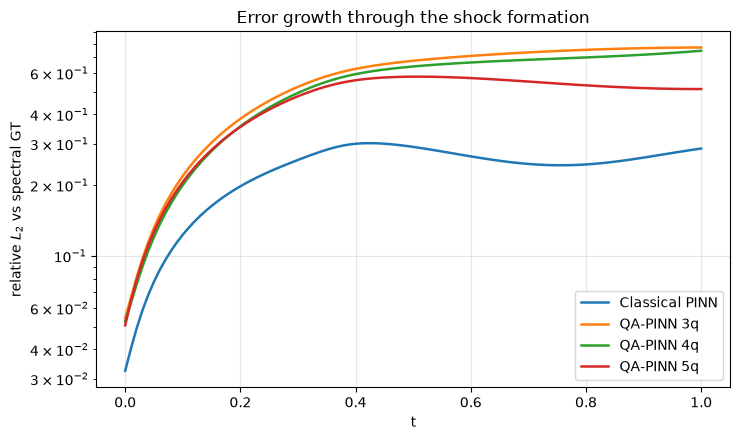

      FDM vs spectral  FEM vs spectral
0.25         0.000622         0.000304
0.50         0.002166         0.000674
0.75         0.001824         0.000475
1.00         0.001443         0.000377


In [8]:
from compare import summary_table, l2_vs_time_plot

ALL_RES  = {"Classical PINN": res_pinn, **{f"QA-PINN {n}q": qres[n] for n in (3,4,5)}}
ALL_HIST = {"Classical PINN": hist_pinn, **{f"QA-PINN {n}q": qhists[n] for n in (3,4,5)}}
PC = {"Classical PINN": sum(p.numel() for p in pinn.parameters()),
      **{f"QA-PINN {n}q": sum(p.numel() for p in qmodels[n].parameters()) for n in (3,4,5)}}

df = summary_table(ALL_RES, ALL_HIST, PC); display(df)
l2_vs_time_plot(ALL_RES)

# Solver-vs-solver L2 (numerical reference accuracy floor)
import pandas as pd
print(pd.DataFrame(xval, index=["FDM vs spectral","FEM vs spectral"]).T)